In [1]:
# 1. Import Library & Konfigurasi
import os
import json
import pickle
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import re
import math
import ipaddress
import tldextract
from urllib.parse import urlparse, urljoin
import pathlib

RANDOM_STATE = 12
TEST_SIZE = 0.2
TARGET_COL = "label"
GA_POP_SIZE = 16
GA_N_GEN = 8
GA_CXPB = 0.7
GA_MUTPB = 0.3
GA_CV_SPLITS = 3

# Path dataset berbasis lokasi notebook
notebook_dir = pathlib.Path().resolve()
data_file_path = str(notebook_dir / "DataFiles" / "data_cleaning.csv")

# Konstanta fitur
url_features_37 = [
    "length_url", "length_hostname", "ip", "nb_dots", "nb_hyphens", "nb_at", "nb_qm", "nb_and",
    "nb_eq", "nb_underscore", "nb_tilde", "nb_percent", "nb_slash", "nb_star", "nb_colon",
    "nb_comma", "nb_semicolumn", "nb_dollar", "nb_space", "nb_www", "nb_com", "nb_dslash",
    "http_in_path", "https_token", "ratio_digits_url", "ratio_digits_host", "punycode", "port",
    "tld_in_path", "tld_in_subdomain", "abnormal_subdomain", "nb_subdomains", "prefix_suffix",
    "random_domain", "shortening_service", "path_extension", "nb_redirection"
]


c:\Users\ASUS\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\ASUS\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 2. Load & Audit Dataset

In [2]:
# Load dataset
import pathlib
notebook_path = pathlib.Path().resolve()
data_file_path = str(notebook_path / "DataFiles" / "data_cleaning.csv")
print('Cek path dataset:', data_file_path)
if not os.path.exists(data_file_path):
    raise FileNotFoundError(f"Dataset tidak ditemukan: {data_file_path}")

df = pd.read_csv(data_file_path)
df.columns = df.columns.str.strip()

# Ringkasan dimensi dataset
df_summary = pd.DataFrame({
    "Metrik": ["Total Baris", "Total Kolom"],
    "Nilai": [df.shape[0], df.shape[1]]
})

dup_cols = df.columns[df.columns.duplicated()].tolist()
whitespace_cols = [c for c in df.columns if c != c.strip()]

df_audit = pd.DataFrame({
    "Jenis Pengecekan": ["Status Duplikasi", "Status Spasi Tersembunyi"],
    "Status": [
        "✅ Aman" if not dup_cols else "⚠️ Terdeteksi",
        "✅ Aman" if not whitespace_cols else "⚠️ Terdeteksi"
    ],
})

print("📊 RINGKASAN DATASET")
display(df_summary)
print("\n🔍 AUDIT STRUKTUR KOLOM")
display(df_audit)
print("\n👀 SAMPEL 2 DATA TERATAS")
display(df.head(2))

Cek path dataset: D:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_cleaning.csv
📊 RINGKASAN DATASET


,Metrik,Nilai
0,Total Baris,11429
1,Total Kolom,83



🔍 AUDIT STRUKTUR KOLOM


,Jenis Pengecekan,Status
0,Status Duplikasi,✅ Aman
1,Status Spasi Tersembunyi,✅ Aman



👀 SAMPEL 2 DATA TERATAS


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,label
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,0
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,1


## 3. Feature Engineering (Ekstraksi Fitur URL)

In [3]:
# Utility & Feature Extraction Functions (disarikan dari app.py)
SHORTENERS = {
    "bit.ly", "goo.gl", "tinyurl.com", "ow.ly", "t.co", "is.gd", "buff.ly",
    "adf.ly", "bit.do", "cutt.ly"
}
SUSPICIOUS_TLD = [
    "zip", "xyz", "top", "tk", "ga", "ml", "gq", "cf", "pw", "cc", "club",
    "ws", "biz", "online", "site", "live", "work", "icu", "info",
    "cn", "ru", "loan", "download", "click"
]
STANDARD_PORTS = {21, 22, 23, 80, 443, 445, 1433, 1521, 3306, 3389}
PHISH_HINTS = [
    "login", "verify", "update", "secure", "account", "bank",
    "paypal", "apple", "microsoft", "confirm", "signin", "password"
]
BRANDS = [
    "google", "facebook", "apple", "microsoft", "amazon", "paypal",
    "instagram", "whatsapp", "telegram", "netflix", "github", "linkedin"
]
PREFILTER_HARD_PHISHING_SCORE = 7

def entropy(s):
    if not s:
        return 0.0
    probs = [s.count(c) / len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in probs)

def parse_url(url):
    u = (url or "").strip()
    if not u.startswith(("http://", "https://")):
        u = "http://" + u
    parsed = urlparse(u)
    hostname = (parsed.hostname or "").lower()
    path = parsed.path or ""
    return u, parsed, hostname, path

def is_ip(hostname):
    try:
        ipaddress.ip_address(hostname)
        return 1
    except Exception:
        return 0

def extract_url_features(url):
    full, parsed, hostname, path = parse_url(url)
    ext = tldextract.extract(full)
    subdomain = (ext.subdomain or "").lower()
    domain = (ext.domain or "").lower()
    suffix = (ext.suffix or "").lower()
    digits_url = sum(c.isdigit() for c in full)
    digits_host = sum(c.isdigit() for c in hostname)
    random_domain = 1 if entropy(domain) > 3.5 else 0
    shortening_service = 1 if any(s in hostname for s in SHORTENERS) else 0
    prefix_suffix = 1 if "-" in domain else 0
    path_extension = 1 if "." in path.split("/")[-1] else 0
    nb_redirection = max(full.lower().count("http") - 1, 0)
    try:
        parsed_port = parsed.port
    except ValueError:
        parsed_port = None
    port_flag = 1 if (parsed_port is not None and parsed_port not in STANDARD_PORTS) else 0
    tld_last_label = suffix.split(".")[-1] if suffix else ""
    suspicious_tld_flag = 1 if (suffix in SUSPICIOUS_TLD or tld_last_label in SUSPICIOUS_TLD) else 0
    domain_in_brand = 1 if any(b in domain for b in BRANDS) else 0
    brand_in_subdomain = 1 if any(b in subdomain for b in BRANDS) else 0
    brand_in_path = 1 if any(b in path.lower() for b in BRANDS) else 0
    statistical_report = 1 if (
        suspicious_tld_flag == 1
        or is_ip(hostname) == 1
        or full.count("@") >= 1
        or random_domain == 1
    ) else 0
    return {
        "length_url": len(full),
        "length_hostname": len(hostname),
        "ip": is_ip(hostname),
        "nb_dots": full.count("."),
        "nb_hyphens": full.count("-"),
        "nb_at": full.count("@"),
        "nb_qm": full.count("?"),
        "nb_and": full.count("&"),
        "nb_eq": full.count("="),
        "nb_underscore": full.count("_"),
        "nb_tilde": full.count("~"),
        "nb_percent": full.count("%"),
        "nb_slash": full.count("/"),
        "nb_star": full.count("*"),
        "nb_colon": full.count(":"),
        "nb_comma": full.count(","),
        "nb_semicolumn": full.count(";"),
        "nb_dollar": full.count("$"),
        "nb_space": full.count(" "),
        "nb_www": 1 if "www" in hostname else 0,
        "nb_com": full.count(".com"),
        "nb_dslash": full.count("//"),
        "http_in_path": 1 if "http" in path else 0,
        "https_token": 1 if "https" in full.replace("https://", "") else 0,
        "ratio_digits_url": digits_url / max(len(full), 1),
        "ratio_digits_host": digits_host / max(len(hostname), 1),
        "punycode": 1 if "xn--" in hostname else 0,
        "port": port_flag,
        "tld_in_path": 1 if suffix and (suffix in path) else 0,
        "tld_in_subdomain": 1 if suffix and (suffix in subdomain) else 0,
        "abnormal_subdomain": 1 if ("http" in subdomain or "https" in subdomain) else 0,
        "nb_subdomains": len(subdomain.split(".")) if subdomain else 0,
        "prefix_suffix": prefix_suffix,
        "random_domain": random_domain,
        "shortening_service": shortening_service,
        "path_extension": path_extension,
        "nb_redirection": nb_redirection,
        "nb_external_redirection": 0,
        "length_words_raw": len(re.findall(r"[A-Za-z0-9]+", full.lower())),
        "char_repeat": sum(1 for i in range(1, len(full)) if full[i] == full[i - 1]),
        "shortest_words_raw": 0,
        "shortest_word_host": 0,
        "shortest_word_path": 0,
        "longest_words_raw": 0,
        "longest_word_host": 0,
        "longest_word_path": 0,
        "avg_words_raw": 0.0,
        "avg_word_host": 0.0,
        "avg_word_path": 0.0,
        "phish_hints": sum(1 for k in PHISH_HINTS if k in full.lower()),
        "domain_in_brand": domain_in_brand,
        "brand_in_subdomain": brand_in_subdomain,
        "brand_in_path": brand_in_path,
        "suspicious_tld": suspicious_tld_flag,
        "statistical_report": statistical_report,
    }


## 4. Split Data & Preprocessing

In [4]:
# Pilih mode fitur: 'hybrid81' (default) atau 'url37'
ACTIVE_TRAIN_FEATURES = "hybrid81"  # atau "url37"

id_cols = [c for c in ["url"] if c in df.columns]
all_features = [c for c in df.columns if c not in [TARGET_COL] + id_cols]
webcontent_features_44 = [c for c in all_features if c not in url_features_37]
hybrid_features_81 = url_features_37 + webcontent_features_44
feature_candidates = hybrid_features_81 if ACTIVE_TRAIN_FEATURES == "hybrid81" else url_features_37

# Cegah error jika ada fitur kandidat yang tidak tersedia
available_features = [c for c in feature_candidates if c in df.columns]
missing_features = [c for c in feature_candidates if c not in df.columns]
if missing_features:
    print(f"⚠️ Fitur tidak ditemukan dan diabaikan: {len(missing_features)} kolom")

# Siapkan X dan y
X_all = df[available_features].apply(pd.to_numeric, errors="coerce")
y_all = pd.to_numeric(df[TARGET_COL], errors="coerce").fillna(0).astype("int64")

# Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=RANDOM_STATE
)

# Filter fitur valid (minimal ada nilai non-NaN di train)
selected_features = X_train.columns[X_train.notna().any()].tolist()
X_train = X_train[selected_features]
X_test = X_test[selected_features]

# Imputasi median dari train
med_all = X_train.median(numeric_only=True)
X_train = X_train.fillna(med_all)
X_test = X_test.fillna(med_all)

# Output ringkasan
df_config = pd.DataFrame({
    "Pengaturan Pemodelan": [
        "Kolom Target", "Mode Pelatihan",
        "Total Kandidat Fitur", "Fitur Tersedia",
        "Jumlah Fitur Valid", "Strategi Imputasi"
    ],
    "Keterangan": [
        TARGET_COL,
        ACTIVE_TRAIN_FEATURES,
        len(feature_candidates),
        len(available_features),
        len(selected_features),
        "Median (dari Data Train)"
    ]
})

df_split = pd.DataFrame({
    "Dataset": ["Train Data (80%)", "Test Data (20%)"],
    "Jumlah Baris": [X_train.shape[0], X_test.shape[0]],
    "Jumlah Kolom (Fitur)": [X_train.shape[1], X_test.shape[1]]
})

print("⚙️ KONFIGURASI:")
display(df_config)
print("\n📊 DIMENSI DATASET:")
display(df_split)

⚙️ KONFIGURASI:


,Pengaturan Pemodelan,Keterangan
0,Kolom Target,label
1,Mode Pelatihan,hybrid81
2,Total Kandidat Fitur,81
3,Fitur Tersedia,81
4,Jumlah Fitur Valid,81
5,Strategi Imputasi,Median (dari Data Train)



📊 DIMENSI DATASET:


,Dataset,Jumlah Baris,Jumlah Kolom (Fitur)
0,Train Data (80%),9143,81
1,Test Data (20%),2286,81


## 5. Rule-Based Filtering & Evaluasi

In [5]:
def rule_based_eval(feats):
    very_important = {
        "suspicious_tld": (feats.get("suspicious_tld", 0) == 1),
        "nb_at": (feats.get("nb_at", 0) >= 1),
        "ip": (feats.get("ip", 0) == 1),
        "nb_underscore": (feats.get("nb_underscore", 0) > 3),
    }
    important = {
        "ratio_digits_url": (feats.get("ratio_digits_url", 0) > 0.3),
        "nb_subdomains": (feats.get("nb_subdomains", 0) > 3),
        "nb_percent": (feats.get("nb_percent", 0) > 5),
        "nb_tilde": (feats.get("nb_tilde", 0) >= 1),
        "nb_semicolumn": (feats.get("nb_semicolumn", 0) >= 1),
        "nb_star": (feats.get("nb_star", 0) >= 1),
        "nb_comma": (feats.get("nb_comma", 0) >= 1),
        "random_domain": (feats.get("random_domain", 0) == 1),
    }
    less_important = {
        "length_hostname": (feats.get("length_hostname", 0) > 30),
        "nb_dollar": (feats.get("nb_dollar", 0) >= 1),
        "nb_qm": (feats.get("nb_qm", 0) > 2),
        "nb_colon": (feats.get("nb_colon", 0) > 1),
        "nb_eq": (feats.get("nb_eq", 0) > 8),
        "nb_dots": (feats.get("nb_dots", 0) > 4),
        "nb_slash": (feats.get("nb_slash", 0) > 7),
        "nb_and": (feats.get("nb_and", 0) > 3),
        "nb_hyphens": (feats.get("nb_hyphens", 0) > 3),
        "http_in_path": (feats.get("http_in_path", 0) == 1),
        "https_token": (feats.get("https_token", 0) == 1),
        "port": (feats.get("port", 0) == 1),
        "shortening_service": (feats.get("shortening_service", 0) == 1),
    }
    vi_count = sum(very_important.values())
    imp_count = sum(important.values())
    less_count = sum(less_important.values())
    risk_score = (3 * vi_count) + (2 * imp_count) + less_count
    rule_flag = int((vi_count >= 1) or (risk_score >= PREFILTER_HARD_PHISHING_SCORE))
    return risk_score, rule_flag

# Evaluasi rule-based pada data test
X_test_url = df.loc[X_test.index, "url"] if "url" in df.columns else None
if X_test_url is not None:
    feats_list = [extract_url_features(u) for u in X_test_url]
else:
    feats_list = [dict(zip(X_test.columns, row)) for row in X_test.values]

rule_results = [rule_based_eval(f) for f in feats_list]
risk_scores = [r[0] for r in rule_results]
y_pred_rule = np.array([r[1] for r in rule_results])

# Confusion matrix & metrik
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rule, labels=[0, 1]).ravel()
cm_table = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual Benign (0)", "Actual Phishing (1)"],
    columns=["Benign (0)", "Phishing (1)"]
)
accuracy = accuracy_score(y_test, y_pred_rule)
precision = precision_score(y_test, y_pred_rule, zero_division=0)
recall = recall_score(y_test, y_pred_rule, zero_division=0)
f1 = f1_score(y_test, y_pred_rule, zero_division=0)
try:
    auc = roc_auc_score(y_test, y_pred_rule)
except Exception:
    auc = np.nan
print("\n🧩 CONFUSION MATRIX (Rule-Based):")
display(cm_table)
print("\n📈 PERFORMANCE METRICS (Rule-Based):")
metrics_df = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"],
    "Score": [accuracy, precision, recall, f1, auc if not np.isnan(auc) else 0],
    "Persentase": [
        f"{accuracy*100:.2f}%",
        f"{precision*100:.2f}%",
        f"{recall*100:.2f}%",
        f"{f1*100:.2f}%",
        f"{auc*100:.2f}%" if not np.isnan(auc) else "N/A"
    ]
})
display(metrics_df)


🧩 CONFUSION MATRIX (Rule-Based):


,Benign (0),Phishing (1)
Actual Benign (0),1099,44
Actual Phishing (1),1016,127



📈 PERFORMANCE METRICS (Rule-Based):


,Metrik,Score,Persentase
0,Accuracy,0.536308,53.63%
1,Precision,0.742690,74.27%
2,Recall,0.111111,11.11%
3,F1 Score,0.193303,19.33%
4,AUC,0.536308,53.63%


## 6. Genetic Algorithm Tuning & Training Model

In [6]:
# Tuning & Training Model (mengadopsi train_model.py, GA tuning)
def clamp(v, lo, hi):
    return max(lo, min(hi, v))

def ensure_deap_creator(name, base_cls, **kwargs):
    if hasattr(creator, name):
        return getattr(creator, name)
    creator.create(name, base_cls, **kwargs)
    return getattr(creator, name)

def tune_rf_ga(X_train, y_train):
    ensure_deap_creator("FitnessMaxRF", base.Fitness, weights=(1.0,))
    rf_ind_cls = ensure_deap_creator("IndividualRF", list, fitness=creator.FitnessMaxRF)
    cv = StratifiedKFold(n_splits=GA_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    def init_ind():
        return rf_ind_cls([
            random.randint(100, 500),
            random.randint(3, 16),
            random.randint(2, 20),
            random.randint(1, 10),
            random.randint(0, 2),
        ])
    def decode(ind):
        max_feat = {0: "sqrt", 1: "log2", 2: None}[int(clamp(round(ind[4]), 0, 2))]
        return {
            "n_estimators": int(clamp(round(ind[0]), 100, 500)),
            "max_depth": int(clamp(round(ind[1]), 3, 16)),
            "min_samples_split": int(clamp(round(ind[2]), 2, 20)),
            "min_samples_leaf": int(clamp(round(ind[3]), 1, 10)),
            "max_features": max_feat,
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }
    def evaluate(ind):
        params = decode(ind)
        model = RandomForestClassifier(**params)
        score = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
        return (float(score),)
    toolbox = base.Toolbox()
    toolbox.register("individual", init_ind)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register(
        "mutate",
        tools.mutUniformInt,
        low=[100, 3, 2, 1, 0],
        up=[500, 16, 20, 10, 2],
        indpb=0.25
    )
    toolbox.register("select", tools.selTournament, tournsize=3)
    pop = toolbox.population(n=GA_POP_SIZE)
    hof = tools.HallOfFame(1)
    algorithms.eaSimple(
        pop,
        toolbox,
        cxpb=GA_CXPB,
        mutpb=GA_MUTPB,
        ngen=GA_N_GEN,
        halloffame=hof,
        verbose=False
    )
    best_params = decode(hof[0])
    best_score = float(hof[0].fitness.values[0])
    print("[GA] RF best CV F1:", round(best_score, 4))
    print("[GA] RF best params:", best_params)
    return best_params, best_score

def tune_xgb_ga(X_train, y_train):
    ensure_deap_creator("FitnessMaxXGB", base.Fitness, weights=(1.0,))
    xgb_ind_cls = ensure_deap_creator("IndividualXGB", list, fitness=creator.FitnessMaxXGB)
    cv = StratifiedKFold(n_splits=GA_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    def init_ind():
        return xgb_ind_cls([
            random.randint(150, 500),
            random.uniform(0.01, 0.30),
            random.randint(3, 10),
            random.uniform(0.60, 1.00),
            random.uniform(0.60, 1.00),
            random.uniform(1.0, 10.0),
            random.uniform(0.0, 5.0),
            random.uniform(0.0, 5.0),
            random.uniform(0.1, 10.0),
        ])
    def decode(ind):
        return {
            "n_estimators": int(clamp(round(ind[0]), 150, 500)),
            "learning_rate": float(clamp(ind[1], 0.01, 0.30)),
            "max_depth": int(clamp(round(ind[2]), 3, 10)),
            "subsample": float(clamp(ind[3], 0.60, 1.00)),
            "colsample_bytree": float(clamp(ind[4], 0.60, 1.00)),
            "min_child_weight": float(clamp(ind[5], 1.0, 10.0)),
            "gamma": float(clamp(ind[6], 0.0, 5.0)),
            "reg_alpha": float(clamp(ind[7], 0.0, 5.0)),
            "reg_lambda": float(clamp(ind[8], 0.1, 10.0)),
            "eval_metric": "logloss",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }
    def evaluate(ind):
        params = decode(ind)
        model = XGBClassifier(**params)
        score = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
        return (float(score),)
    def mutate(ind, indpb=0.25):
        for i in range(len(ind)):
            if random.random() < indpb:
                if i in (0, 2):
                    ind[i] += random.randint(-30, 30)
                else:
                    ind[i] += random.uniform(-0.2, 0.2)
        return (ind,)
    toolbox = base.Toolbox()
    toolbox.register("individual", init_ind)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", mutate, indpb=0.3)
    toolbox.register("select", tools.selTournament, tournsize=3)
    pop = toolbox.population(n=GA_POP_SIZE)
    hof = tools.HallOfFame(1)
    algorithms.eaSimple(
        pop,
        toolbox,
        cxpb=GA_CXPB,
        mutpb=GA_MUTPB,
        ngen=GA_N_GEN,
        halloffame=hof,
        verbose=False
    )
    best_params = decode(hof[0])
    best_score = float(hof[0].fitness.values[0])
    print("[GA] XGB best CV F1:", round(best_score, 4))
    print("[GA] XGB best params:", best_params)
    return best_params, best_score

# Training model utama
def train_models(X_train, y_train):
    best_rf_params, _ = tune_rf_ga(X_train, y_train)
    best_xgb_params, _ = tune_xgb_ga(X_train, y_train)
    rf_model = RandomForestClassifier(**best_rf_params)
    rf_model.fit(X_train, y_train)
    xgb_model = XGBClassifier(**best_xgb_params)
    xgb_model.fit(X_train, y_train)
    stack_model = StackingClassifier(
        estimators=[("rf", rf_model), ("xgb", xgb_model)],
        final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
        stack_method="predict_proba",
        n_jobs=-1
    )
    stack_model.fit(X_train, y_train)
    return rf_model, xgb_model, stack_model

rf_ga, xgb_ga, stack_ga = train_models(X_train, y_train)

[GA] RF best CV F1: 0.9623
[GA] RF best params: {'n_estimators': 296, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'random_state': 12, 'n_jobs': -1}
[GA] XGB best CV F1: 0.9649
[GA] XGB best params: {'n_estimators': 452, 'learning_rate': 0.07695944405169254, 'max_depth': 10, 'subsample': 0.6, 'colsample_bytree': 0.6767408771106374, 'min_child_weight': 2.743745305773983, 'gamma': 1.6457847651447133, 'reg_alpha': 0.3244547704789841, 'reg_lambda': 1.0847258357939562, 'eval_metric': 'logloss', 'random_state': 12, 'n_jobs': -1}


## 7. Evaluasi Model (RF, XGB, Stacking, Hybrid)

In [7]:
def evaluate_model(name, model, X_eval, y_eval):
    y_prob = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else np.zeros(len(X_eval))
    y_pred = (y_prob >= 0.6).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred, labels=[0, 1]).ravel()
    try:
        auc = roc_auc_score(y_eval, y_prob)
    except Exception:
        auc = np.nan
    cm_table = pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=["Actual Benign (0)", "Actual Phishing (1)"],
        columns=["Benign (0)", "Phishing (1)"]
    )
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1 Score": f1_score(y_eval, y_pred, zero_division=0),
        "AUC": auc,
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "cm_table": cm_table
    }

def hybrid_predict_efficient(X_eval, rule_series, stacking_model, confidence_phishing=0.95):
    rule_arr = rule_series.reindex(X_eval.index).fillna(0).astype(int).values
    idx_caught  = np.where(rule_arr == 1)[0]
    idx_escaped = np.where(rule_arr == 0)[0]
    n_total   = len(X_eval)
    n_caught  = len(idx_caught)
    n_escaped = len(idx_escaped)
    final_pred  = np.zeros(n_total, dtype=int)
    final_proba = np.zeros(n_total, dtype=float)
    final_pred[idx_caught]  = 1
    final_proba[idx_caught] = confidence_phishing
    if n_escaped > 0:
        X_escaped        = X_eval.iloc[idx_escaped]
        stk_pred         = stacking_model.predict(X_escaped)
        stk_proba        = stacking_model.predict_proba(X_escaped)[:, 1]
        final_pred[idx_escaped]  = stk_pred
        final_proba[idx_escaped] = stk_proba
    return final_pred, final_proba, n_caught, n_escaped

y_pred_rule_series = pd.Series(y_pred_rule, index=X_test.index)
results = [
    evaluate_model("Random Forest (GA)", rf_ga, X_test, y_test),
    evaluate_model("XGBoost (GA)", xgb_ga, X_test, y_test),
    evaluate_model("Stacking (RF+XGB+LR, GA)", stack_ga, X_test, y_test),
]
# Hybrid
hyb_pred, hyb_proba, n_caught, n_escaped = hybrid_predict_efficient(X_test, y_pred_rule_series, stack_ga)
hyb_eval = evaluate_model("Hybrid (Rule+Stacking)", stack_ga, X_test, y_test)
hyb_eval["TP"] = int(((hyb_pred == 1) & (y_test == 1)).sum())
hyb_eval["TN"] = int(((hyb_pred == 0) & (y_test == 0)).sum())
hyb_eval["FP"] = int(((hyb_pred == 1) & (y_test == 0)).sum())
hyb_eval["FN"] = int(((hyb_pred == 0) & (y_test == 1)).sum())
hyb_eval["cm_table"] = pd.DataFrame(
    [[hyb_eval["TN"], hyb_eval["FP"]], [hyb_eval["FN"], hyb_eval["TP"]]],
    index=["Actual Benign (0)", "Actual Phishing (1)"],
    columns=["Benign (0)", "Phishing (1)"]
)
results.append(hyb_eval)

# Leaderboard metrik
detail_df = pd.DataFrame([{k: v for k, v in e.items() if k != "cm_table"} for e in results])
print(f"📊 PERBANDINGAN PERFORMA MODEL PADA DATA TEST (Threshold Phishing = 0.6)")
display(detail_df)
for e in results:
    print(f"\n🧩 CONFUSION MATRIX - {e['Model']}")
    display(e["cm_table"])

📊 PERBANDINGAN PERFORMA MODEL PADA DATA TEST (Threshold Phishing = 0.6)


,Model,Accuracy,Precision,Recall,F1 Score,AUC,TP,TN,FP,FN
0,Random Forest (GA),0.968941,0.983755,0.953631,0.968458,0.995420,1090,1125,18,53
1,XGBoost (GA),0.975503,0.980548,0.970254,0.975374,0.996487,1109,1121,22,34
2,"Stacking (RF+XGB+LR, GA)",0.973753,0.977935,0.969379,0.973638,0.996197,1108,1118,25,35
3,Hybrid (Rule+Stacking),0.973753,0.977935,0.969379,0.973638,0.996197,1117,1071,72,26



🧩 CONFUSION MATRIX - Random Forest (GA)


,Benign (0),Phishing (1)
Actual Benign (0),1125,18
Actual Phishing (1),53,1090



🧩 CONFUSION MATRIX - XGBoost (GA)


,Benign (0),Phishing (1)
Actual Benign (0),1121,22
Actual Phishing (1),34,1109



🧩 CONFUSION MATRIX - Stacking (RF+XGB+LR, GA)


,Benign (0),Phishing (1)
Actual Benign (0),1118,25
Actual Phishing (1),35,1108



🧩 CONFUSION MATRIX - Hybrid (Rule+Stacking)


,Benign (0),Phishing (1)
Actual Benign (0),1071,72
Actual Phishing (1),26,1117


## 8. Perbandingan Performa & Latency

In [8]:
import time  # Tambahkan ini di awal cell
def evaluate_batch(name, predict_fn, X_eval, y_eval, n_runs=5):
    times = []
    y_pred_last = None
    y_prob_last = None
    for _ in range(n_runs):
        t0 = time.time()
        result = predict_fn(X_eval)
        times.append(time.time() - t0)
        y_pred_last = result[0]
        y_prob_last = result[1]
    avg_time   = np.mean(times)
    throughput = len(X_eval) / avg_time
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred_last, labels=[0, 1]).ravel()
    try:
        auc = roc_auc_score(y_eval, y_prob_last)
    except Exception:
        auc = np.nan
    cm_table = pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=["Actual Benign (0)", "Actual Phishing (1)"],
        columns=["Predicted Benign (0)", "Predicted Phishing (1)"]
    )
    return {
        "Model"              : name,
        "Accuracy"           : accuracy_score(y_eval, y_pred_last),
        "Precision"          : precision_score(y_eval, y_pred_last, zero_division=0),
        "Recall"             : recall_score(y_eval, y_pred_last, zero_division=0),
        "F1-Score"           : f1_score(y_eval, y_pred_last, zero_division=0),
        "AUC"                : auc,
        "Batch Time (s)"     : round(avg_time, 6),
        "Throughput (URL/s)" : round(throughput, 1),
        "TP": int(tp), "TN": int(tn),
        "FP": int(fp), "FN": int(fn),
        "cm_table"           : cm_table
    }

def evaluate_latency(name, predict_fn, X_single, n_runs=20):
    times = []
    for _ in range(n_runs):
        t0 = time.time()
        predict_fn(X_single)
        times.append(time.time() - t0)
    return {
        "Model"         : name,
        "Latency (ms)"  : round(np.mean(times) * 1000, 3),
        "Min (ms)"      : round(np.min(times)  * 1000, 3),
        "Max (ms)"      : round(np.max(times)  * 1000, 3),
        "Std (ms)"      : round(np.std(times)  * 1000, 3),
    }

batch_results = []
batch_results.append(evaluate_batch(
    "Random Forest",
    lambda X: (rf_ga.predict(X), rf_ga.predict_proba(X)[:, 1]),
    X_test, y_test
) )
batch_results.append(evaluate_batch(
    "XGBoost",
    lambda X: (xgb_ga.predict(X), xgb_ga.predict_proba(X)[:, 1]),
    X_test, y_test
) )
batch_results.append(evaluate_batch(
    "Stacking",
    lambda X: (stack_ga.predict(X), stack_ga.predict_proba(X)[:, 1]),
    X_test, y_test
) )
batch_results.append(evaluate_batch(
    "Hybrid (Rule+Stacking)",
    lambda X: hybrid_predict_efficient(X, y_pred_rule_series, stack_ga)[:2],
    X_test, y_test
) )
batch_df = pd.DataFrame(batch_results)

X_single           = X_test.iloc[[0]]
y_rule_single      = y_pred_rule_series.iloc[[0]]
latency_results = []
latency_results.append(evaluate_latency(
    "Random Forest",
    lambda X: (rf_ga.predict(X), rf_ga.predict_proba(X)[:, 1]),
    X_single
) )
latency_results.append(evaluate_latency(
    "XGBoost",
    lambda X: (xgb_ga.predict(X), xgb_ga.predict_proba(X)[:, 1]),
    X_single
) )
latency_results.append(evaluate_latency(
    "Stacking",
    lambda X: (stack_ga.predict(X), stack_ga.predict_proba(X)[:, 1]),
    X_single
) )
latency_results.append(evaluate_latency(
    "Hybrid (Rule+Stacking)",
    lambda X: hybrid_predict_efficient(X, y_rule_single, stack_ga)[:2],
    X_single
) )
latency_df = pd.DataFrame(latency_results)

print("\n📊 TABEL PERBANDINGAN BATCH (Seluruh Data Test)")
display(
    batch_df[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC", "Batch Time (s)", "Throughput (URL/s)", "TP", "TN", "FP", "FN"]]
)
print("\n⚡ TABEL LATENCY PER 1 URL")
display(latency_df)


📊 TABEL PERBANDINGAN BATCH (Seluruh Data Test)


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Batch Time (s),Throughput (URL/s),TP,TN,FP,FN
0,Random Forest,0.971566,0.971154,0.972003,0.971578,0.995420,0.281385,8124.1,1111,1110,33,32
1,XGBoost,0.977690,0.974783,0.980752,0.977758,0.996487,0.109162,20941.4,1121,1114,29,22
2,Stacking,0.974628,0.975460,0.973753,0.974606,0.996197,0.394714,5791.5,1113,1115,28,30
3,Hybrid (Rule+Stacking),0.957130,0.939445,0.977253,0.957976,0.990542,0.367587,6218.9,1117,1071,72,26



⚡ TABEL LATENCY PER 1 URL


,Model,Latency (ms),Min (ms),Max (ms),Std (ms)
0,Random Forest,109.463,80.994,167.154,21.979
1,XGBoost,95.175,77.761,118.945,11.528
2,Stacking,266.795,241.194,320.314,20.413
3,Hybrid (Rule+Stacking),294.088,202.090,421.144,56.410


In [9]:
# Evaluasi Batch Keempat Model
batch_results = []
 
# Model 1: Random Forest
batch_results.append(evaluate_batch(
    "Random Forest",
    lambda X: (rf_ga.predict(X), rf_ga.predict_proba(X)[:, 1]),
    X_test, y_test
))
 
# Model 2: XGBoost
batch_results.append(evaluate_batch(
    "XGBoost",
    lambda X: (xgb_ga.predict(X), xgb_ga.predict_proba(X)[:, 1]),
    X_test, y_test
))
 
# Model 3: Stacking
batch_results.append(evaluate_batch(
    "Stacking",
    lambda X: (stack_ga.predict(X), stack_ga.predict_proba(X)[:, 1]),
    X_test, y_test
))
 
# Model 4: Hybrid EFISIEN (Rule-Based → hanya sisa URL masuk Stacking)
batch_results.append(evaluate_batch(
    "Hybrid (Rule+Stacking)",
    lambda X: hybrid_predict_efficient(X, y_pred_rule_series, stack_ga)[:2],
    X_test, y_test
))
 
batch_df = pd.DataFrame(batch_results)

X_single           = X_test.iloc[[0]]
y_rule_single      = y_pred_rule_series.iloc[[0]]
 
latency_results = []
 
latency_results.append(evaluate_latency(
    "Random Forest",
    lambda X: (rf_ga.predict(X), rf_ga.predict_proba(X)[:, 1]),
    X_single
))
 
latency_results.append(evaluate_latency(
    "XGBoost",
    lambda X: (xgb_ga.predict(X), xgb_ga.predict_proba(X)[:, 1]),
    X_single
))
 
latency_results.append(evaluate_latency(
    "Stacking",
    lambda X: (stack_ga.predict(X), stack_ga.predict_proba(X)[:, 1]),
    X_single
))
 
latency_results.append(evaluate_latency(
    "Hybrid (Rule+Stacking)",
    lambda X: hybrid_predict_efficient(X, y_rule_single, stack_ga)[:2],
    X_single
))
 
latency_df = pd.DataFrame(latency_results)

In [10]:
n_test = len(X_test)

print("\n📊 TABEL PERBANDINGAN BATCH (Seluruh Data Test)")
display(
    batch_df[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC",
              "Batch Time (s)", "Throughput (URL/s)", "TP", "TN", "FP", "FN"]]
    .style
    .format({
        "Accuracy"           : "{:.6f}",
        "Precision"          : "{:.6f}",
        "Recall"             : "{:.6f}",
        "F1-Score"           : "{:.6f}",
        "AUC"                : "{:.6f}",  
        "Batch Time (s)"     : "{:.6f}",
        "Throughput (URL/s)" : "{:.1f}",
    })
    .background_gradient(
        cmap="Greens",
        subset=["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]  
    )
    .background_gradient(
        cmap="YlOrRd_r",
        subset=["Batch Time (s)"]
    )
    .background_gradient(
        cmap="Blues",
        subset=["Throughput (URL/s)", "TP", "TN"]
    )
    .background_gradient(
        cmap="Reds_r",
        subset=["FP", "FN"]
    )
    .set_properties(**{"text-align": "center", "vertical-align": "middle"})
    .set_caption(f"Batch Performance pada {n_test} URL Data Test")
)


📊 TABEL PERBANDINGAN BATCH (Seluruh Data Test)


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Batch Time (s),Throughput (URL/s),TP,TN,FP,FN
0,Random Forest,0.971566,0.971154,0.972003,0.971578,0.995420,0.648047,3527.5,1111,1110,33,32
1,XGBoost,0.977690,0.974783,0.980752,0.977758,0.996487,0.341332,6697.3,1121,1114,29,22
2,Stacking,0.974628,0.975460,0.973753,0.974606,0.996197,1.096294,2085.2,1113,1115,28,30
3,Hybrid (Rule+Stacking),0.957130,0.939445,0.977253,0.957976,0.990542,1.271264,1798.2,1117,1071,72,26


# 10. Execution Time

In [11]:
# Tabel Styled — Latency per 1 URL
print("\n⚡ TABEL LATENCY PER 1 URL")
display(
    latency_df.style
    .format({
        "Latency (ms)": "{:.3f}",
        "Min (ms)"    : "{:.3f}",
        "Max (ms)"    : "{:.3f}",
        "Std (ms)"    : "{:.3f}",
    })
    .background_gradient(cmap="YlOrRd_r", subset=["Latency (ms)"])
    .background_gradient(cmap="Oranges",  subset=["Min (ms)", "Max (ms)", "Std (ms)"])
    .set_properties(**{"text-align": "center", "vertical-align": "middle"})
    .set_caption("Latency Prediksi per 1 URL (rata-rata 20 percobaan)")
)
 



⚡ TABEL LATENCY PER 1 URL


,Model,Latency (ms),Min (ms),Max (ms),Std (ms)
0,Random Forest,422.128,255.588,645.982,107.344
1,XGBoost,243.173,181.147,386.553,53.010
2,Stacking,592.535,489.182,774.240,78.185
3,Hybrid (Rule+Stacking),1608.857,591.328,3785.199,837.234


## 11. SHAP

📊 SHAP (SHapley Additive exPlanations) - MODEL INTERPRETABILITY

1️⃣ SHAP UNTUK XGBoost MODEL

🔄 Membuat SHAP Explainer untuk XGBoost...

📊 1. Feature Importance (XGBoost) - Bar Plot


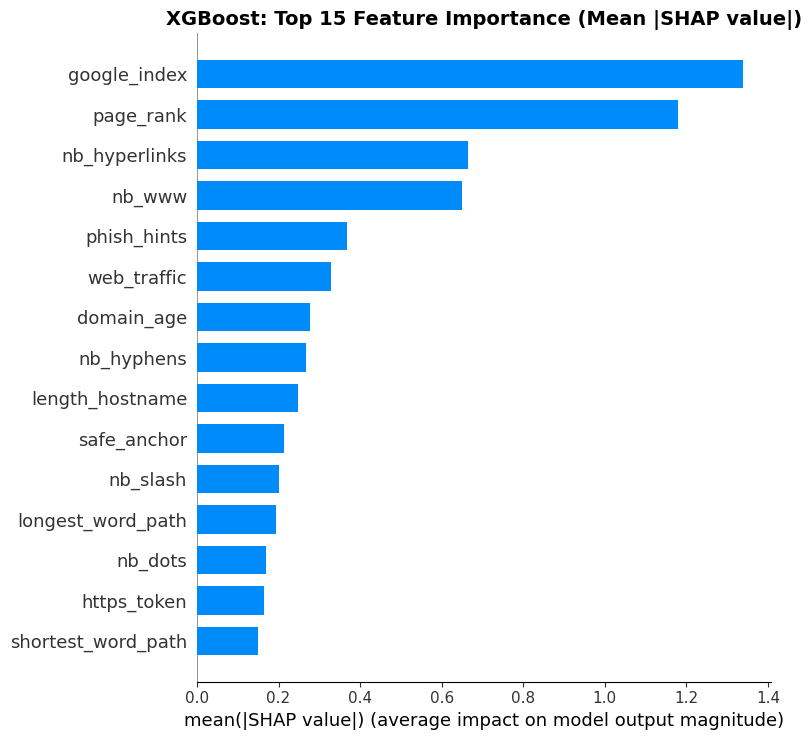


📊 2. Feature Contribution Pattern (XGBoost) - Violin Plot


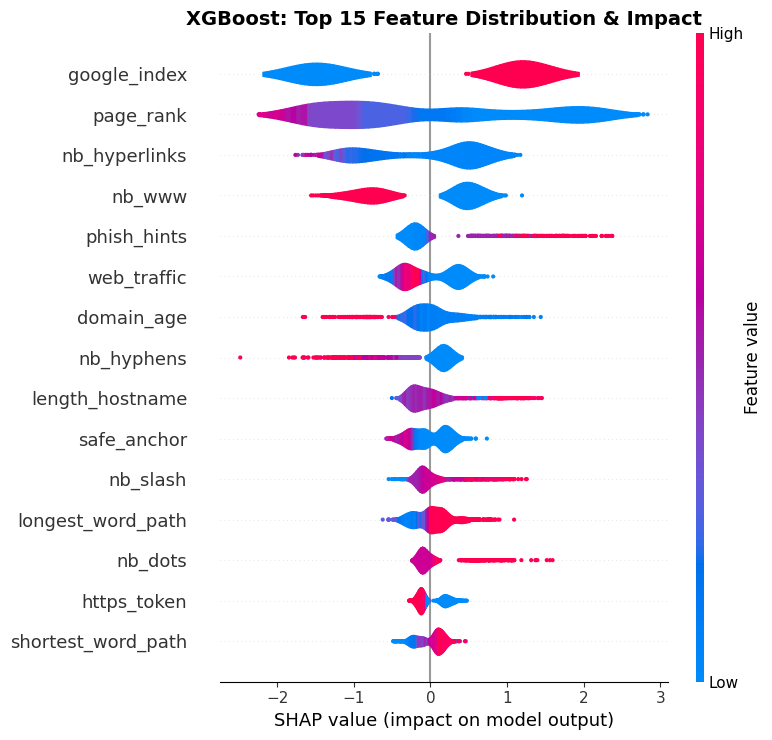


📊 3. Feature Dependence Plots (XGBoost) - Top 4 Features


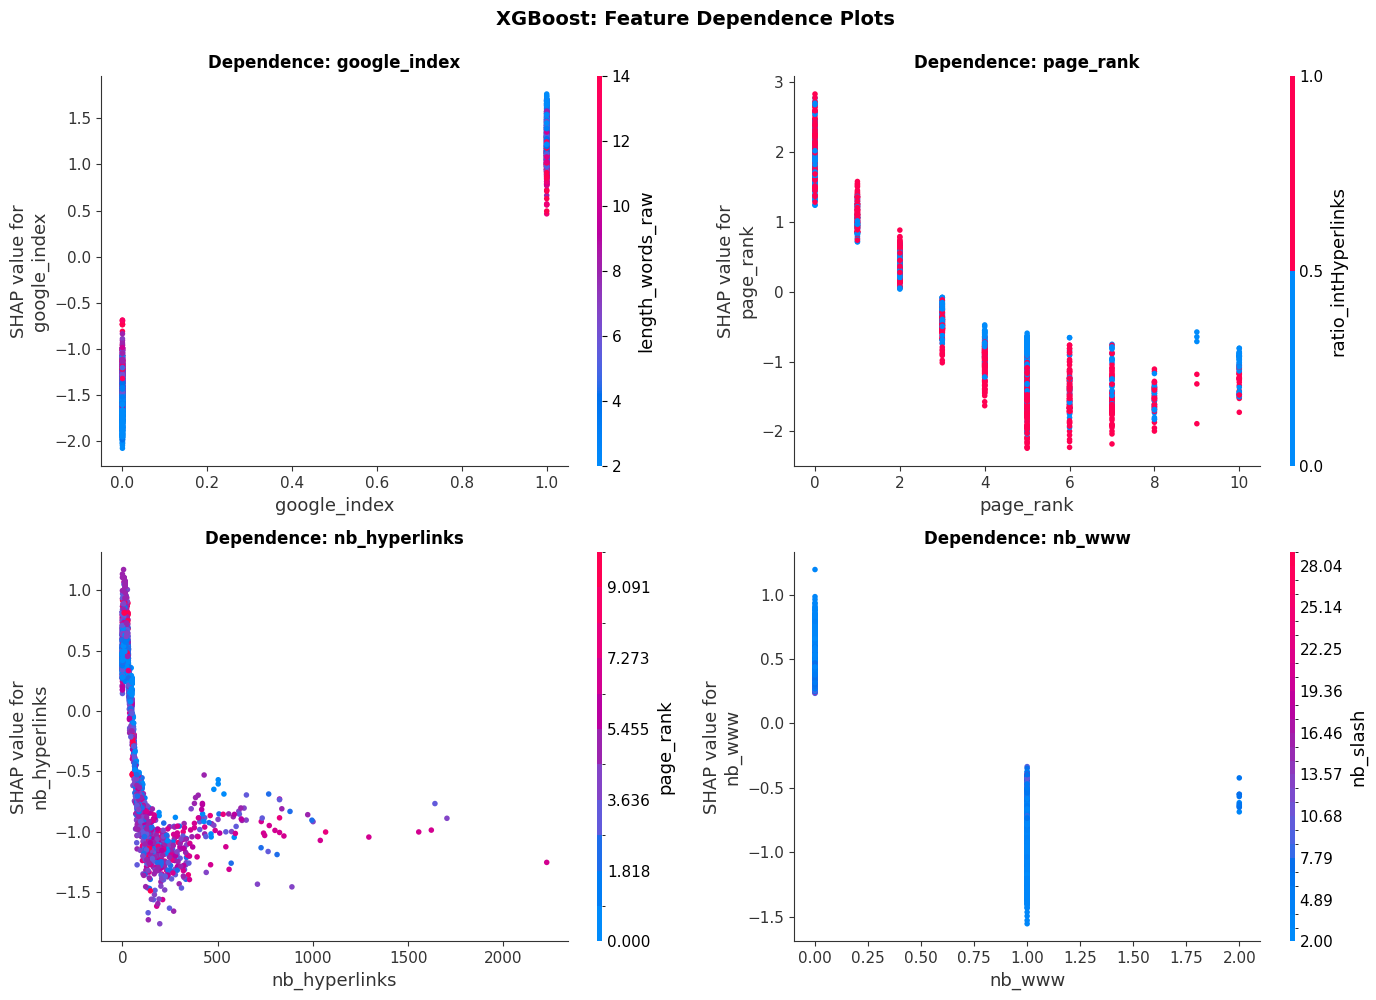


📊 4. Force Plot Examples (XGBoost)

  a) Sample Prediksi Phishing (Index=0):


<Figure size 1400x400 with 0 Axes>

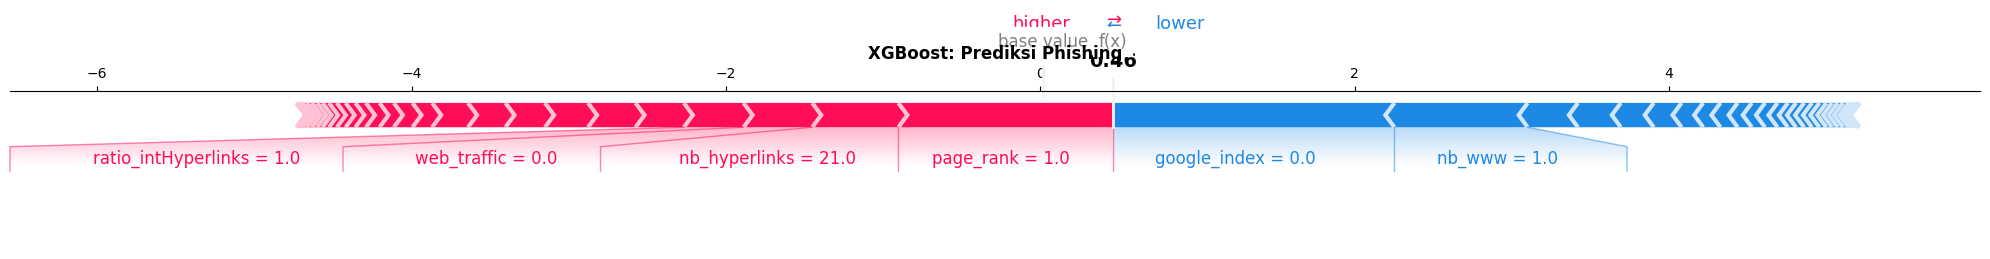


  b) Sample Prediksi Benign (Index=3):


<Figure size 1400x400 with 0 Axes>

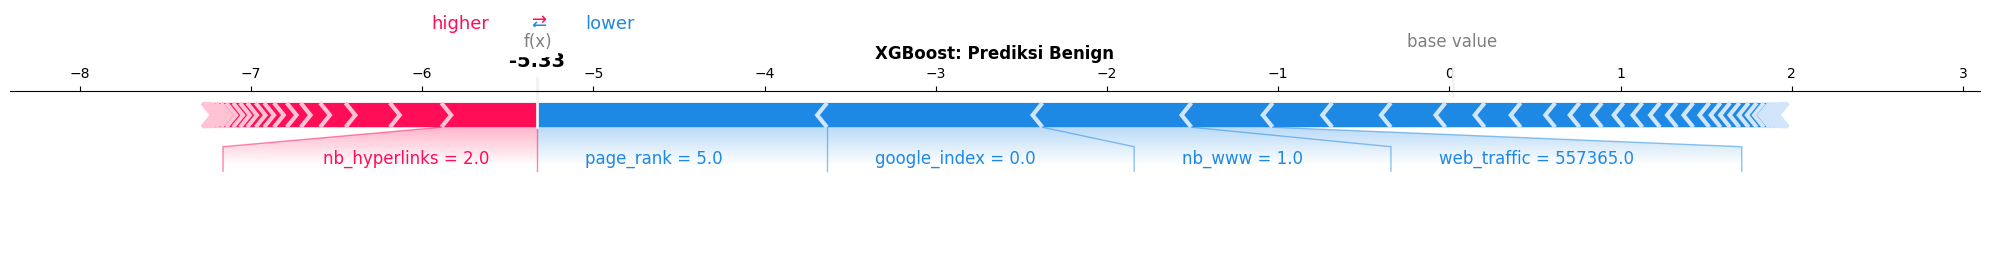


📊 5. Waterfall Plot - Detail Contribution (XGBoost)
   Menunjukkan kontribusi setiap feature untuk prediksi sampel Phishing (Index=0)



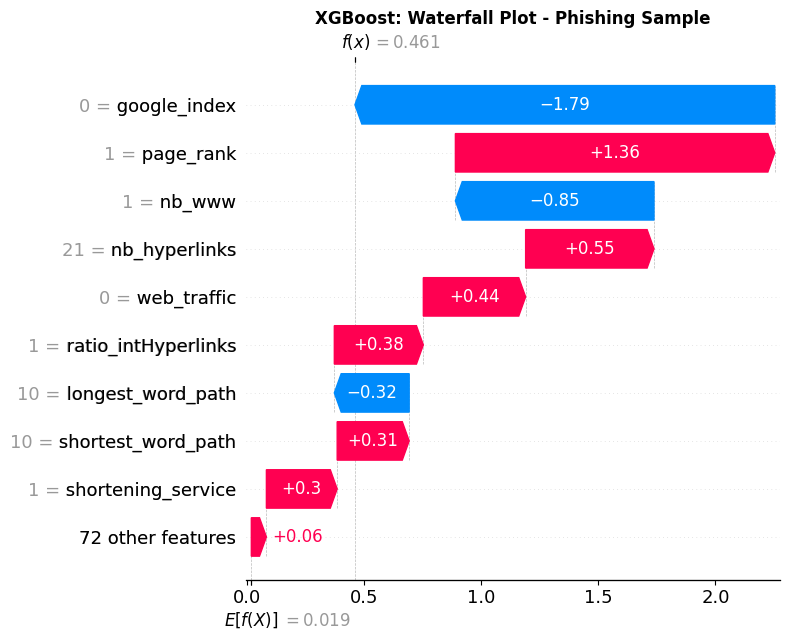


✅ XGBoost SHAP Analysis Selesai!

2️⃣ SHAP UNTUK RANDOM FOREST MODEL

🔄 Membuat SHAP Explainer untuk Random Forest...

📊 1. Feature Importance (Random Forest) - Bar Plot


<Figure size 1200x600 with 0 Axes>

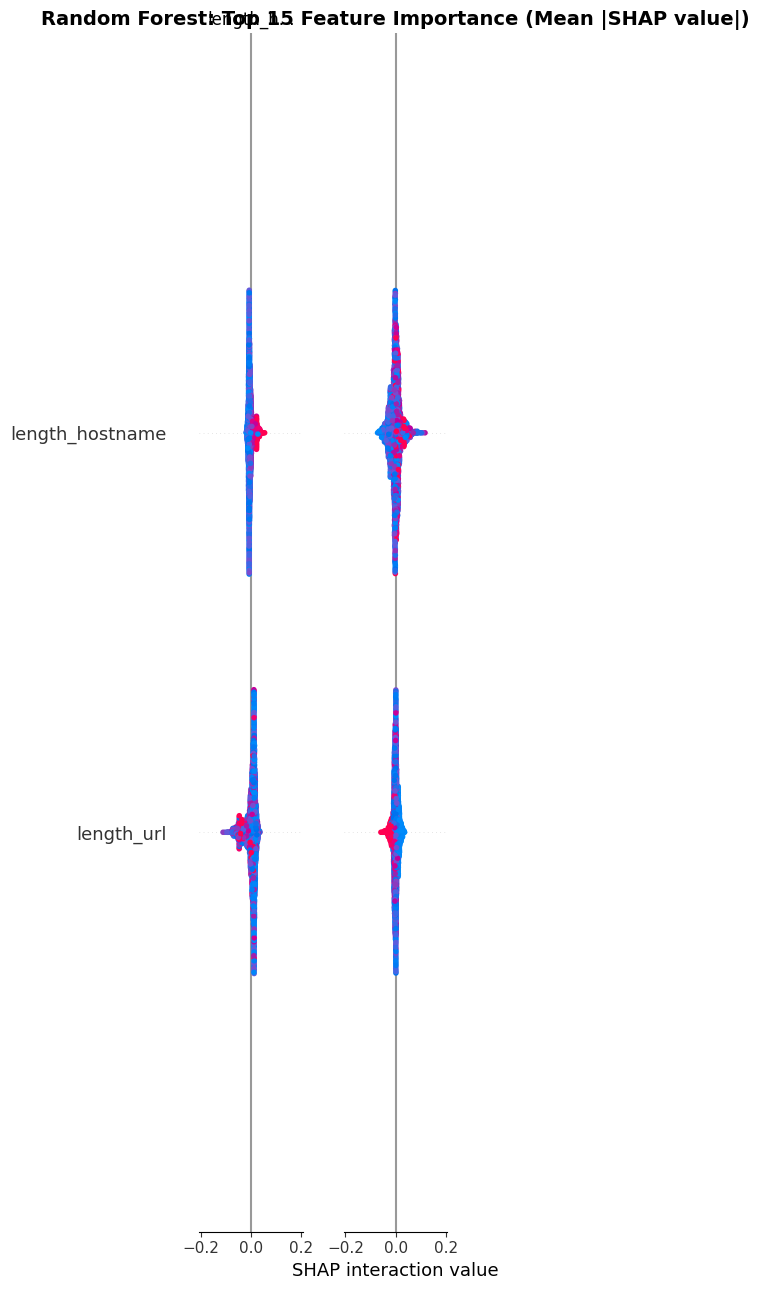


📊 2. Feature Contribution Pattern (Random Forest) - Violin Plot


<Figure size 1200x800 with 0 Axes>

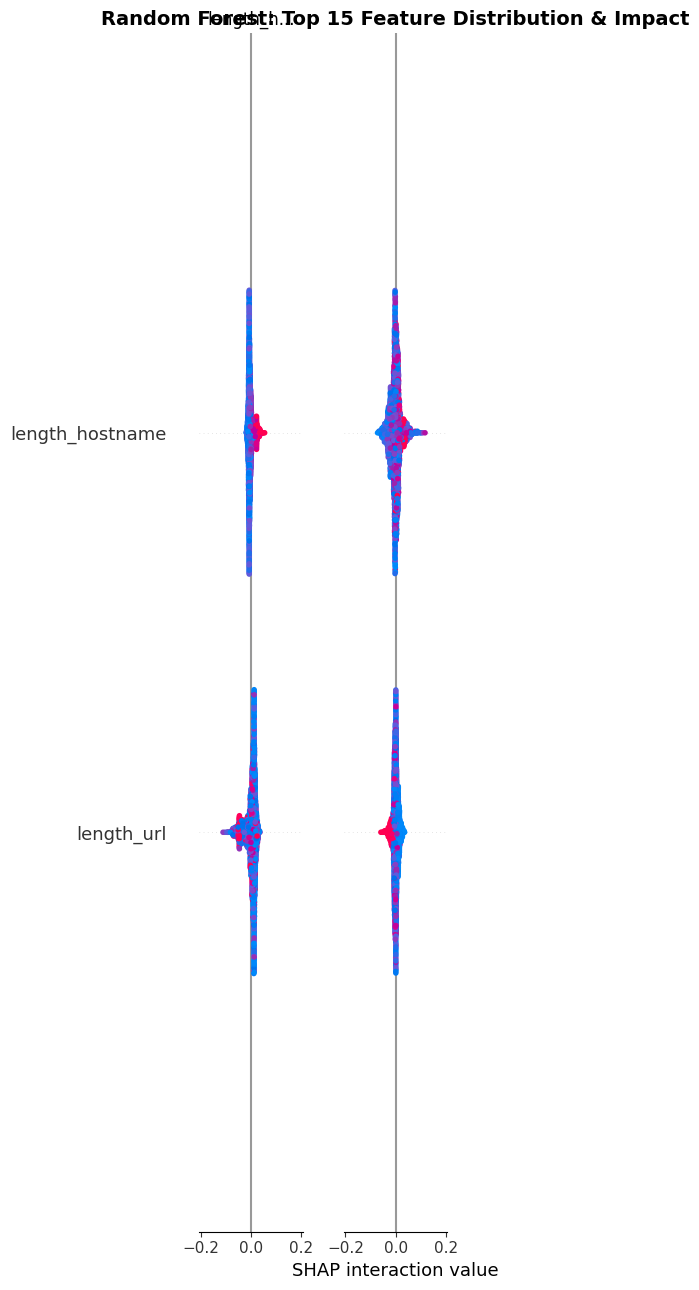


📊 3. Feature Dependence Plots (Random Forest) - Top 4 Features
❌ Error dalam Random Forest SHAP: only integer scalar arrays can be converted to a scalar index

📈 PERBANDINGAN SHAP STATISTICS - XGBoost vs Random Forest

Top 15 Features Comparison:


,Feature,XGBoost (Mean |SHAP|),Random Forest (Mean |SHAP|),Difference
0,length_url,0.1117,0.0070,0.1047
1,length_hostname,0.2470,0.0081,0.2389
2,ip,0.0903,0.0081,0.0821
3,nb_dots,0.1692,0.0081,0.1611
4,nb_hyphens,0.2686,0.0057,0.2629
5,nb_at,0.0000,0.0004,0.0004
6,nb_qm,0.1173,0.0064,0.1109
7,nb_and,0.0011,0.0011,0.0001
8,nb_eq,0.0609,0.0055,0.0554
9,nb_underscore,0.0514,0.0013,0.0501



✅ Keseluruhan SHAP Analysis Selesai!


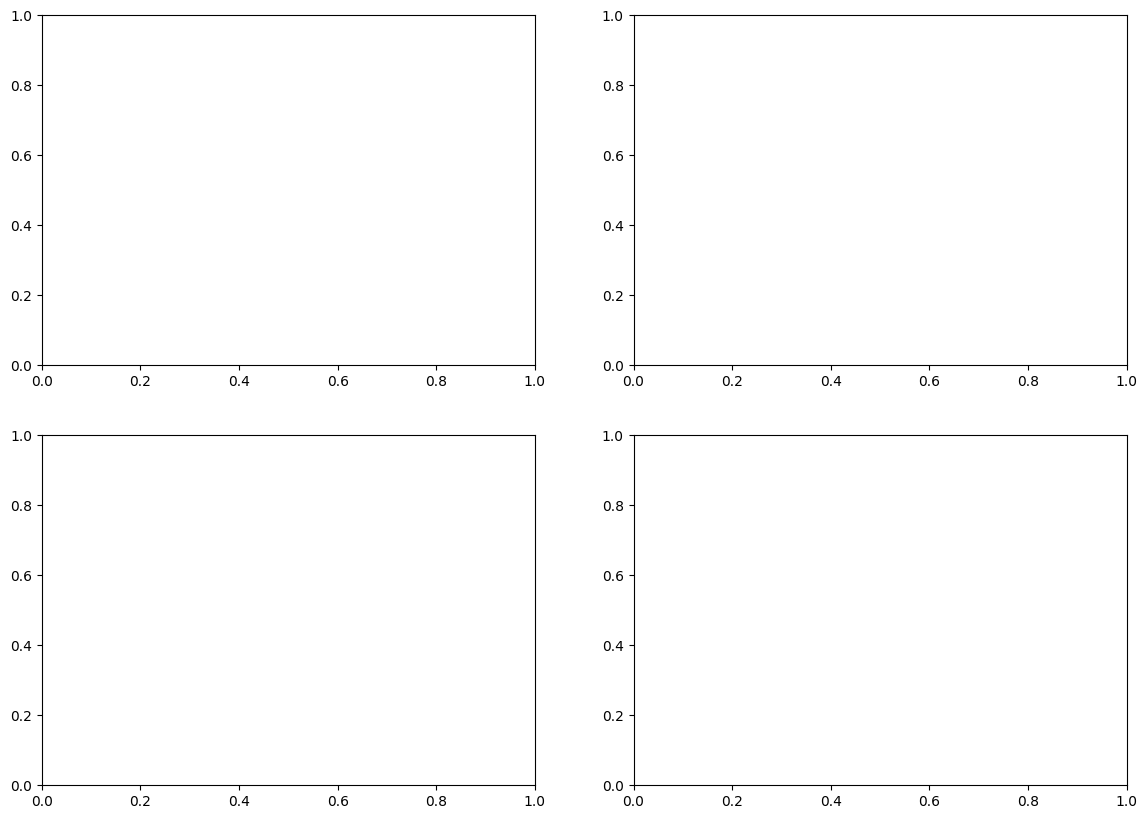

In [12]:
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib backend untuk jupyter
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

print("=" * 80)
print("📊 SHAP (SHapley Additive exPlanations) - MODEL INTERPRETABILITY")
print("=" * 80)

# ============================================================================
# SHAP untuk XGBoost
# ============================================================================
print("\n" + "=" * 80)
print("1️⃣ SHAP UNTUK XGBoost MODEL")
print("=" * 80)

# Buat explainer untuk XGBoost
print("\n🔄 Membuat SHAP Explainer untuk XGBoost...")
try:
    explainer_xgb = shap.TreeExplainer(xgb_ga)
    shap_values_xgb = explainer_xgb.shap_values(X_test)
    
    # Summary Plot - Bar (Top 15 features)
    print("\n📊 1. Feature Importance (XGBoost) - Bar Plot")
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values_xgb, X_test, plot_type='bar', max_display=15, show=False)
    plt.title("XGBoost: Top 15 Feature Importance (Mean |SHAP value|)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # Summary Plot - Violin (Top 15 features)
    print("\n📊 2. Feature Contribution Pattern (XGBoost) - Violin Plot")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_xgb, X_test, plot_type='violin', max_display=15, show=False)
    plt.title("XGBoost: Top 15 Feature Distribution & Impact", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # Dependence Plot untuk top 4 features
    print("\n📊 3. Feature Dependence Plots (XGBoost) - Top 4 Features")
    feature_names = X_test.columns.tolist()
    
    # Hitung feature importance untuk menentukan top 4
    mean_abs_shap = np.abs(shap_values_xgb).mean(axis=0)
    top_4_indices = np.argsort(mean_abs_shap)[-4:][::-1]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, feature_idx in enumerate(top_4_indices):
        feature_name = feature_names[feature_idx]
        shap.dependence_plot(feature_idx, shap_values_xgb, X_test, ax=axes[idx], show=False)
        axes[idx].set_title(f"Dependence: {feature_name}", fontweight='bold')
    
    plt.suptitle("XGBoost: Feature Dependence Plots", fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # Force Plot untuk sample Phishing
    print("\n📊 4. Force Plot Examples (XGBoost)")
    phishing_idx = np.where(y_test == 1)[0][0] if (y_test == 1).any() else 0
    benign_idx = np.where(y_test == 0)[0][0] if (y_test == 0).any() else 0
    
    print(f"\n  a) Sample Prediksi Phishing (Index={phishing_idx}):")
    plt.figure(figsize=(14, 4))
    shap.force_plot(explainer_xgb.expected_value, shap_values_xgb[phishing_idx], 
                    X_test.iloc[phishing_idx], show=False, matplotlib=True)
    plt.title(f"XGBoost: Prediksi Phishing", fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print(f"\n  b) Sample Prediksi Benign (Index={benign_idx}):")
    plt.figure(figsize=(14, 4))
    shap.force_plot(explainer_xgb.expected_value, shap_values_xgb[benign_idx], 
                    X_test.iloc[benign_idx], show=False, matplotlib=True)
    plt.title(f"XGBoost: Prediksi Benign", fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # Waterfall Plot (Detailed prediction explanation)
    print("\n📊 5. Waterfall Plot - Detail Contribution (XGBoost)")
    print(f"   Menunjukkan kontribusi setiap feature untuk prediksi sampel Phishing (Index={phishing_idx})\n")
    plt.figure(figsize=(12, 8))
    shap.plots.waterfall(shap.Explanation(values=shap_values_xgb[phishing_idx], 
                                           base_values=explainer_xgb.expected_value, 
                                           data=X_test.iloc[phishing_idx],
                                           feature_names=feature_names), show=False)
    plt.title(f"XGBoost: Waterfall Plot - Phishing Sample", fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print("\n✅ XGBoost SHAP Analysis Selesai!")
    
except Exception as e:
    print(f"❌ Error dalam XGBoost SHAP: {str(e)}")

# ============================================================================
# SHAP untuk Random Forest
# ============================================================================
print("\n" + "=" * 80)
print("2️⃣ SHAP UNTUK RANDOM FOREST MODEL")
print("=" * 80)

# Buat explainer untuk Random Forest
print("\n🔄 Membuat SHAP Explainer untuk Random Forest...")
try:
    explainer_rf = shap.TreeExplainer(rf_ga)
    shap_values_rf = explainer_rf.shap_values(X_test)
    
    # Untuk Random Forest (binary classification), ambil kelas positif jika ada 2 output
    if isinstance(shap_values_rf, list):
        shap_values_rf = shap_values_rf[1]
    
    # Summary Plot - Bar (Top 15 features)
    print("\n📊 1. Feature Importance (Random Forest) - Bar Plot")
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values_rf, X_test, plot_type='bar', max_display=15, show=False)
    plt.title("Random Forest: Top 15 Feature Importance (Mean |SHAP value|)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # Summary Plot - Violin (Top 15 features)
    print("\n📊 2. Feature Contribution Pattern (Random Forest) - Violin Plot")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_rf, X_test, plot_type='violin', max_display=15, show=False)
    plt.title("Random Forest: Top 15 Feature Distribution & Impact", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # Dependence Plot untuk top 4 features
    print("\n📊 3. Feature Dependence Plots (Random Forest) - Top 4 Features")
    
    # Hitung feature importance untuk menentukan top 4
    mean_abs_shap_rf = np.abs(shap_values_rf).mean(axis=0)
    top_4_indices_rf = np.argsort(mean_abs_shap_rf)[-4:][::-1]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, feature_idx in enumerate(top_4_indices_rf):
        feature_name = feature_names[feature_idx]
        shap.dependence_plot(feature_idx, shap_values_rf, X_test, ax=axes[idx], show=False)
        axes[idx].set_title(f"Dependence: {feature_name}", fontweight='bold')
    
    plt.suptitle("Random Forest: Feature Dependence Plots", fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # Force Plot untuk sample Phishing
    print("\n📊 4. Force Plot Examples (Random Forest)")
    print(f"\n  a) Sample Prediksi Phishing (Index={phishing_idx}):")
    plt.figure(figsize=(14, 4))
    shap.force_plot(explainer_rf.expected_value, shap_values_rf[phishing_idx], 
                    X_test.iloc[phishing_idx], show=False, matplotlib=True)
    plt.title(f"Random Forest: Prediksi Phishing", fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print(f"\n  b) Sample Prediksi Benign (Index={benign_idx}):")
    plt.figure(figsize=(14, 4))
    shap.force_plot(explainer_rf.expected_value, shap_values_rf[benign_idx], 
                    X_test.iloc[benign_idx], show=False, matplotlib=True)
    plt.title(f"Random Forest: Prediksi Benign", fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # Waterfall Plot (Detailed prediction explanation)
    print("\n📊 5. Waterfall Plot - Detail Contribution (Random Forest)")
    print(f"   Menunjukkan kontribusi setiap feature untuk prediksi sampel Phishing (Index={phishing_idx})\n")
    plt.figure(figsize=(12, 8))
    shap.plots.waterfall(shap.Explanation(values=shap_values_rf[phishing_idx], 
                                           base_values=explainer_rf.expected_value, 
                                           data=X_test.iloc[phishing_idx],
                                           feature_names=feature_names), show=False)
    plt.title(f"Random Forest: Waterfall Plot - Phishing Sample", fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print("\n✅ Random Forest SHAP Analysis Selesai!")
    
except Exception as e:
    print(f"❌ Error dalam Random Forest SHAP: {str(e)}")

# ============================================================================
# Perbandingan SHAP Value Statistics
# ============================================================================
print("\n" + "=" * 80)
print("📈 PERBANDINGAN SHAP STATISTICS - XGBoost vs Random Forest")
print("=" * 80)

try:
    # Create comparison table
    comparison_data = []
    for i, fname in enumerate(feature_names[:15]):  # Top 15 features
        xgb_mean = np.abs(shap_values_xgb[:, i]).mean()
        rf_mean = np.abs(shap_values_rf[:, i]).mean()
        comparison_data.append({
            "Feature": fname,
            "XGBoost (Mean |SHAP|)": f"{xgb_mean:.4f}",
            "Random Forest (Mean |SHAP|)": f"{rf_mean:.4f}",
            "Difference": f"{abs(xgb_mean - rf_mean):.4f}"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print("\nTop 15 Features Comparison:")
    display(comparison_df)
    
    print("\n✅ Keseluruhan SHAP Analysis Selesai!")
    print("=" * 80)
    
except Exception as e:
    print(f"❌ Error dalam pembuatan comparison table: {str(e)}")